### 함수
* CSV 파일을 읽어 딕셔너리 리스트로 변환하는 함수 작성
* 학생 중 성적이 80점 이상인 학생만 필터링
* 필터링된 학생들의 평균 나이 계산
* 모든 함수 호출 시간을 측정하는 데코레이터 적용

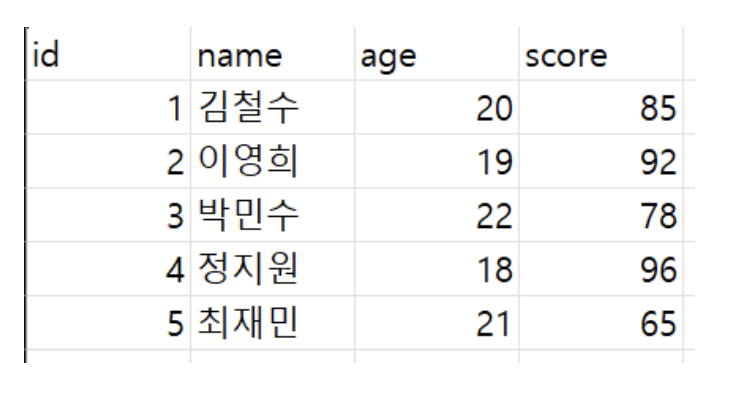

In [5]:
import csv
import time

def measure_time(func):
    """함수의 실행 시간을 측정하여 출력하는 데코레이터입니다."""
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"'{func.__name__}' 함수 실행 시간: {end_time - start_time:.6f}초")
        return result
    return wrapper

@measure_time
def read_students_from_csv(filename):
    """CSV 파일을 읽어와 학생 정보가 담긴 딕셔너리의 리스트로 반환합니다."""
    students = []
    with open(filename, mode='r', encoding='utf-8') as file:
        csv_reader = csv.DictReader(file)
        for row in csv_reader:
            row['id'] = row['id']
            row['name'] = row['name']
            row['age'] = int(row['age'])
            row['score'] = int(row['score'])
            students.append(row)
    return students

@measure_time
def filter_high_scorers(student_list):
    """학생 리스트에서 점수가 80점 이상인 학생만 필터링하여 반환합니다."""
    return [student for student in student_list if student['score'] >= 80]

@measure_time
def calculate_average_age(student_list):
    """학생 리스트의 평균 나이를 계산하여 반환합니다."""
    if not student_list: 
        return 0
    
    total_age = sum(student['age'] for student in student_list)
    return total_age / len(student_list)

print("## 1. CSV 파일 읽기")
all_students = read_students_from_csv('data/students.csv')
print("전체 학생 데이터:")
print(all_students)
print("-" * 40)

print("## 2. 80점 이상 학생 필터링")
high_scorers = filter_high_scorers(all_students)
print("80점 이상 학생 데이터:")
print(high_scorers)
print("-" * 40)

print("## 3. 필터링된 학생들의 평균 나이 계산")
average_age = calculate_average_age(high_scorers)
print(f"80점 이상 학생들의 평균 나이: {average_age:.2f}세")
print("-" * 40)

## 1. CSV 파일 읽기
'read_students_from_csv' 함수 실행 시간: 0.002869초
전체 학생 데이터:
[{'id': '1', 'name': '김철수', 'age': 20, 'score': 85}, {'id': '2', 'name': '이영희', 'age': 19, 'score': 92}, {'id': '3', 'name': '박민수', 'age': 22, 'score': 78}, {'id': '4', 'name': '정지원', 'age': 18, 'score': 96}, {'id': '5', 'name': '최재민', 'age': 21, 'score': 65}]
----------------------------------------
## 2. 80점 이상 학생 필터링
'filter_high_scorers' 함수 실행 시간: 0.000002초
80점 이상 학생 데이터:
[{'id': '1', 'name': '김철수', 'age': 20, 'score': 85}, {'id': '2', 'name': '이영희', 'age': 19, 'score': 92}, {'id': '4', 'name': '정지원', 'age': 18, 'score': 96}]
----------------------------------------
## 3. 필터링된 학생들의 평균 나이 계산
'calculate_average_age' 함수 실행 시간: 0.000004초
80점 이상 학생들의 평균 나이: 19.00세
----------------------------------------


### 모듈과 패키지
* 간단한 계산기 모듈을 만들어 보세요.
    * 모듈에는 덧셈, 뺄셈, 곱셈, 나눗셈 함수가 포함

In [6]:
import modules.my_calculator as calc

print(f"덧셈: 10 + 5 = {calc.add(10, 5)}")
print(f"뺄셈: 10 - 5 = {calc.subtract(10, 5)}")
print(f"곱셈: 10 * 5 = {calc.multiply(10, 5)}")
print(f"나눗셈: 10 / 5 = {calc.divide(10, 5)}")
print("-" * 30)

덧셈: 10 + 5 = 15
뺄셈: 10 - 5 = 5
곱셈: 10 * 5 = 50
나눗셈: 10 / 5 = 2.0
------------------------------


### 클래스와 객체지향
* 다음 클래스를 구현하세요:
    * `Book': 도서 정보(제목, 저자, ISBN, 출판연도 등)를 관리
    * `Library': 도서 컬렉션을 관리하고 대출/반납 기능 제공
    * `Member': 도서관 회원 정보와 대출 목록 관리
* 다음 기능을 구현하세요:
    * 도서 추가/삭제
    * 도서 검색(제목, 저자, ISBN으로)
    * 도서 대출/반납
    * 회원 등록/관리
    * 회원별 대출 현황 확인
* 객체 지향 설계 원칙(SOLID)을 최소한 2가지 이상 적용하세요.
* 적절한 캡슐화를 통해 데이터를 보호하세요.

In [8]:
class Book:
    """도서 정보를 관리하는 클래스"""
    def __init__(self, title, author, isbn, year):
        self.title = title
        self.author = author
        self.isbn = isbn
        self.year = year
        self.is_available = True

    def __str__(self):
        """객체를 문자열로 표현할 때 사용되는 메서드"""
        status = "대출 가능" if self.is_available else "대출 중"
        return f"'{self.title}' by {self.author} ({self.year}) - {status}"
    
class Member:
    """회원 정보와 대출 목록을 관리하는 클래스"""
    def __init__(self, name, member_id):
        self.name = name
        self.member_id = member_id
        self.borrowed_books = []

    def borrow_book(self, book):
        """책을 대출 목록에 추가"""
        self.borrowed_books.append(book)

    def return_book(self, book):
        """책을 대출 목록에서 제거"""
        if book in self.borrowed_books:
            self.borrowed_books.remove(book)

    def __str__(self):
        return f"회원: {self.name} (ID: {self.member_id}), 대출 권수: {len(self.borrowed_books)}"
    
class Library:
    """도서 컬렉션을 관리하고 대출/반납 기능을 제공하는 클래스"""
    def __init__(self):
        self._books = {}
        self._members = {}

    def add_book(self, book):
        """새로운 책을 도서관에 추가"""
        self._books[book.isbn] = book
        print(f"[{book.title}] 책이 추가되었습니다.")

    def remove_book(self, isbn):
        """ISBN으로 책을 찾아 삭제"""
        if isbn in self._books:
            removed_book = self._books.pop(isbn)
            print(f"[{removed_book.title}] 책이 삭제되었습니다.")
        else:
            print("해당 ISBN의 책을 찾을 수 없습니다.")

    def find_book(self, query, search_by='title'):
        """책 검색 기능 (제목, 저자, ISBN)"""
        results = []
        for book in self._books.values():
            if search_by == 'title' and query.lower() in book.title.lower():
                results.append(book)
            elif search_by == 'author' and query.lower() in book.author.lower():
                results.append(book)
            elif search_by == 'isbn' and query == book.isbn:
                results.append(book)
        return results

    def register_member(self, member):
        """새로운 회원 등록"""
        self._members[member.member_id] = member
        print(f"{member.name}님이 회원으로 등록되었습니다.")

    def lend_book(self, isbn, member_id):
        """책 대출 기능"""
        book = self._books.get(isbn)
        member = self._members.get(member_id)

        if not book:
            print("오류: 해당 ISBN의 책이 없습니다.")
            return
        if not member:
            print("오류: 해당 ID의 회원이 없습니다.")
            return
        if not book.is_available:
            print(f"오류: '{book.title}'은(는) 현재 대출 중입니다.")
            return

        book.is_available = False
        member.borrow_book(book)
        print(f"'{book.title}'을(를) {member.name}님에게 대출했습니다.")

    def return_book(self, isbn, member_id):
        """책 반납 기능"""
        book = self._books.get(isbn)
        member = self._members.get(member_id)

        if not book:
            print("오류: 해당 ISBN의 책이 없습니다.")
            return
        if not member:
            print("오류: 해당 ID의 회원이 없습니다.")
            return
        
        if book in member.borrowed_books:
            book.is_available = True
            member.return_book(book)
            print(f"'{book.title}'이(가) {member.name}님으로부터 반납되었습니다.")
        else:
            print("오류: 해당 회원은 이 책을 대출하지 않았습니다.")

    def get_member_loan_status(self, member_id):
        """회원별 대출 현황 확인"""
        member = self._members.get(member_id)
        if member:
            print(f"\n--- {member.name}님의 대출 현황 ---")
            if member.borrowed_books:
                for book in member.borrowed_books:
                    print(f"- {book.title} ({book.isbn})")
            else:
                print("대출한 책이 없습니다.")
            print("--------------------------")
        else:
            print("해당 ID의 회원을 찾을 수 없습니다.")

my_library = Library()

book1 = Book("파이썬 정복", "김파이", "978-1-111-11111-1", 2023)
book2 = Book("AI 시대의 서바이벌 가이드", "이인공", "978-2-222-22222-2", 2024)
book3 = Book("알고리즘과 나", "박자료", "978-3-333-33333-3", 2022)

my_library.add_book(book1)
my_library.add_book(book2)
my_library.add_book(book3)

member1 = Member("라이언", "M001")
member2 = Member("어피치", "M002")

my_library.register_member(member1)
my_library.register_member(member2)

print("\n--- '김파이' 저자의 책 검색 ---")
search_results = my_library.find_book("김파이", search_by='author')
for book in search_results:
    print(book)
print("--------------------------")

print("\n--- 도서 대출 ---")
my_library.lend_book("978-1-111-11111-1", "M001")
my_library.lend_book("978-2-222-22222-2", "M001")
my_library.lend_book("978-1-111-11111-1", "M002")

my_library.get_member_loan_status("M001")
my_library.get_member_loan_status("M002")

print("\n--- 도서 반납 ---")
my_library.return_book("978-1-111-11111-1", "M001")

my_library.get_member_loan_status("M001")

print("\n--- 최종 책 상태 확인 ---")
print(book1)

[파이썬 정복] 책이 추가되었습니다.
[AI 시대의 서바이벌 가이드] 책이 추가되었습니다.
[알고리즘과 나] 책이 추가되었습니다.
라이언님이 회원으로 등록되었습니다.
어피치님이 회원으로 등록되었습니다.

--- '김파이' 저자의 책 검색 ---
'파이썬 정복' by 김파이 (2023) - 대출 가능
--------------------------

--- 도서 대출 ---
'파이썬 정복'을(를) 라이언님에게 대출했습니다.
'AI 시대의 서바이벌 가이드'을(를) 라이언님에게 대출했습니다.
오류: '파이썬 정복'은(는) 현재 대출 중입니다.

--- 라이언님의 대출 현황 ---
- 파이썬 정복 (978-1-111-11111-1)
- AI 시대의 서바이벌 가이드 (978-2-222-22222-2)
--------------------------

--- 어피치님의 대출 현황 ---
대출한 책이 없습니다.
--------------------------

--- 도서 반납 ---
'파이썬 정복'이(가) 라이언님으로부터 반납되었습니다.

--- 라이언님의 대출 현황 ---
- AI 시대의 서바이벌 가이드 (978-2-222-22222-2)
--------------------------

--- 최종 책 상태 확인 ---
'파이썬 정복' by 김파이 (2023) - 대출 가능


### 파일 입출력 & 예외 처리
* 파일 처리기 구현
    * 다양한 유형의 파일(텍스트, CSV, JSON, 바이너리)을 읽고 쓸 수 있어야 합니다
    * 파일이 존재하지 않거나, 권한이 없거나, 형식이 잘못된 경우 등 다양한 오류 상황을 적절히 처리
    * 사용자 정의 예외 계층 구조를 설계하고 구현
    * 오류 발생 시 로깅을 통해 문제를 기록
    * 모든 파일 작업은 컨텍스트 매니저('with` 구문)를 사용

In [14]:
import json
import logging
import csv

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('file_operations.log'),
        logging.StreamHandler()
    ]
)

class FileOperationError(Exception):
    """파일 처리 관련 오류의 기본 클래스"""
    pass

class FileReadError(FileOperationError):
    """파일 읽기 중 발생한 오류"""
    pass

class FileWriteError(FileOperationError):
    """파일 쓰기 중 발생한 오류"""
    pass

class UnsupportedFileTypeError(FileOperationError):
    """지원하지 않는 파일 형식일 때 발생하는 오류"""
    pass

class FileHandler:
    """다양한 파일을 읽고 쓰는 클래스"""

    def read(self, filepath):
        """파일을 확장자에 맞게 읽어 Python 데이터로 반환"""
        try:
            extension = filepath.split('.')[-1].lower()
            
            if extension in ['txt', 'csv', 'json']:
                with open(filepath, 'r', encoding='utf-8') as f:
                    if extension == 'txt':
                        return f.read()
                    elif extension == 'csv':
                        return list(csv.reader(f))
                    elif extension == 'json':
                        return json.load(f)
            
            elif extension == 'bin':
                with open(filepath, 'rb') as f:
                    return f.read()
            else:
                raise UnsupportedFileTypeError(f"'{extension}'은(는) 지원하지 않는 파일 형식입니다.")

        except FileNotFoundError:
            logging.error(f"파일을 찾을 수 없음: {filepath}")
            raise FileReadError(f"파일이 존재하지 않습니다: {filepath}")
        except json.JSONDecodeError:
            logging.error(f"JSON 형식 오류: {filepath}")
            raise FileReadError(f"JSON 파일의 형식이 잘못되었습니다: {filepath}")
        except Exception as e:
            logging.error(f"파일 읽기 중 알 수 없는 오류 발생: {e}")
            raise FileReadError(f"파일을 읽는 중 오류가 발생했습니다: {filepath}")

    def write(self, filepath, data):
        """데이터를 확장자에 맞는 형식으로 파일에 씁니다."""
        extension = filepath.split('.')[-1].lower()

        try:
            if extension in ['txt', 'csv', 'json']:
                with open(filepath, 'w', encoding='utf-8', newline='') as f:
                    if extension == 'txt':
                        f.write(data)
                    elif extension == 'csv':
                        csv.writer(f).writerows(data)
                    elif extension == 'json':
                        json.dump(data, f, indent=4, ensure_ascii=False)
            
            elif extension == 'bin':
                if not isinstance(data, bytes):
                    raise TypeError("바이너리 파일에 쓰려면 데이터가 bytes 타입이어야 합니다.")
                with open(filepath, 'wb') as f:
                    f.write(data)
            else:
                raise UnsupportedFileTypeError(f"'{extension}' 형식의 파일 쓰기는 지원하지 않습니다.")

            logging.info(f"데이터를 성공적으로 저장했습니다: {filepath}")

        except TypeError as e:
            logging.error(f"데이터 타입 오류: {e}")
            raise FileWriteError(f"파일에 쓰기에 부적합한 데이터 타입입니다: {filepath}")
        except Exception as e:
            logging.error(f"파일 쓰기 중 알 수 없는 오류 발생: {e}")
            raise FileWriteError(f"파일을 쓰는 중 오류가 발생했습니다: {filepath}")
        
handler = FileHandler()

print("--- JSON 처리 ---")
json_data = {"id": "kakao123", "level": 5, "active": True}
try:
    handler.write('user_profile.json', json_data)
    read_data = handler.read('user_profile.json')
    
    print(f"읽은 데이터: {read_data}")
    print(f"데이터 타입: {type(read_data)}")
    print(f"사용자 레벨: {read_data['level']}")
except FileOperationError as e:
    print(f"오류 발생: {e}")


print("\n--- 바이너리 처리 ---")
binary_data = b'\x48\x65\x6c\x6c\x6f\x20\x57\x6f\x72\x6c\x64'

try:
    handler.write('raw_data.bin', binary_data)
    read_data = handler.read('raw_data.bin')

    print(f"읽은 데이터: {read_data}")
    print(f"데이터 타입: {type(read_data)}")
    print(f"디코딩된 문자열: {read_data.decode('utf-8')}")
except FileOperationError as e:
    print(f"오류 발생: {e}")


print("\n--- 바이너리 오류 처리 ---")
try:
    handler.write('error.bin', "normal text")
except FileWriteError as e:
    print(f"오류 잡기 성공: {e}")


2025-09-04 15:58:46,850 - INFO - 데이터를 성공적으로 저장했습니다: user_profile.json
2025-09-04 15:58:46,858 - INFO - 데이터를 성공적으로 저장했습니다: raw_data.bin
2025-09-04 15:58:46,863 - ERROR - 데이터 타입 오류: 바이너리 파일에 쓰려면 데이터가 bytes 타입이어야 합니다.


--- JSON 처리 ---
읽은 데이터: {'id': 'kakao123', 'level': 5, 'active': True}
데이터 타입: <class 'dict'>
사용자 레벨: 5

--- 바이너리 처리 ---
읽은 데이터: b'Hello World'
데이터 타입: <class 'bytes'>
디코딩된 문자열: Hello World

--- 바이너리 오류 처리 ---
오류 잡기 성공: 파일에 쓰기에 부적합한 데이터 타입입니다: error.bin


### 이터레이터와 제너레이터
* 로그 파일을 한 줄씩 읽는 제너레이터 함수 작성
* 특정 패턴(예: 'ERROR', 'WARNING' 등)이 포함된 줄만 필터링하는 제너레이터 작성

    ```
    2023-11-20 10:15:32 INFO: 사용자 로그인 성공
    2023-11-20 10:16:45 ERROR: 데이터베이스 연결 실패
    2023-11-20 10:17:23 WARNING: 비정상적인 접근 시도
    2023-11-20 11:05:11 ERROR: 메모리 부족 오류
    2023-11-20 11:10:55 INFO: 시스템 상태 정상
    ```

In [21]:
import os

# 샘플 로그 파일 생성
log_content = """2023-11-20 10:15:32 INFO: 사용자 로그인 성공
2023-11-20 10:16:45 ERROR: 데이터베이스 연결 실패
2023-11-20 10:17:23 WARNING: 비정상적인 접근 시도
2023-11-20 11:05:11 ERROR: 메모리 부족 오류
2023-11-20 11:10:55 INFO: 시스템 상태 정상
"""
log_filename = "system.log"
with open(log_filename, 'w', encoding='utf-8') as f:
    f.write(log_content)

def read_log_lines(filepath):
    """로그 파일을 한 줄씩 읽는 제너레이터"""
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            yield line.strip()

def filter_lines_by_pattern(lines, pattern):
    """주어진 줄들에서 특정 패턴을 포함한 줄만 필터링하는 제너레이터"""
    for line in lines:
        if pattern in line:
            yield line

print("--- ERROR Logs ---")
log_lines = read_log_lines(log_filename)
error_logs = filter_lines_by_pattern(log_lines, 'ERROR')
for log in error_logs:
    print(log)

print("\n--- WARNING Logs ---")
log_lines_again = read_log_lines(log_filename)
warning_logs = filter_lines_by_pattern(log_lines_again, 'WARNING')
for log in warning_logs:
    print(log)

--- ERROR Logs ---
2023-11-20 10:16:45 ERROR: 데이터베이스 연결 실패
2023-11-20 11:05:11 ERROR: 메모리 부족 오류

--- WARNING Logs ---
2023-11-20 10:17:23 WARNING: 비정상적인 접근 시도


### 동시성과 병렬 처리
* 5개의 공개 API URL에 GET 요청을 보냄
* 세 가지 방식으로 구현하고 성능을 비교합니다:
    * 순차 처리
    * ThreadPoolExecutor 사용
    * asyncio와 aiohttp 사용
* API_URLS
    * "https://jsonplaceholder.typicode.com/posts/1",
    * "https://jsonplaceholder.typicode.com/posts/2",
    * "https://jsonplaceholder.typicode.com/posts/3",
    * "https://jsonplaceholder.typicode.com/posts/4",
    * "https://jsonplaceholder.typicode.com/posts/5"

In [22]:
import requests
import time
import concurrent.futures
import asyncio
import aiohttp

API_URLS = [
    "https://jsonplaceholder.typicode.com/posts/1",
    "https://jsonplaceholder.typicode.com/posts/2",
    "https://jsonplaceholder.typicode.com/posts/3",
    "https://jsonplaceholder.typicode.com/posts/4",
    "https://jsonplaceholder.typicode.com/posts/5"
]

def fetch_sync(url):
    response = requests.get(url)
    return response.status_code

async def fetch_async(session, url):
    async with session.get(url) as response:
        return response.status

def run_sequential():
    start_time = time.monotonic()
    results = [fetch_sync(url) for url in API_URLS]
    elapsed_time = time.monotonic() - start_time
    print(f"순차 처리: {elapsed_time:.4f}초, 결과: {results}")

def run_with_threads():
    start_time = time.monotonic()
    with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
        results = list(executor.map(fetch_sync, API_URLS))
    elapsed_time = time.monotonic() - start_time
    print(f"ThreadPoolExecutor: {elapsed_time:.4f}초, 결과: {results}")

async def run_with_asyncio():
    start_time = time.monotonic()
    async with aiohttp.ClientSession() as session:
        tasks = [fetch_async(session, url) for url in API_URLS]
        results = await asyncio.gather(*tasks)
    elapsed_time = time.monotonic() - start_time
    print(f"asyncio/aiohttp: {elapsed_time:.4f}초, 결과: {results}")

print("API 요청 성능 비교 (네트워크 상황에 따라 결과는 달라질 수 있습니다)\n")
run_sequential()
run_with_threads()
await run_with_asyncio()

API 요청 성능 비교 (네트워크 상황에 따라 결과는 달라질 수 있습니다)

순차 처리: 1.3670초, 결과: [200, 200, 200, 200, 200]
ThreadPoolExecutor: 0.5312초, 결과: [200, 200, 200, 200, 200]
asyncio/aiohttp: 0.1633초, 결과: [200, 200, 200, 200, 200]
